In [63]:
%load_ext autoreload
%autoreload 2

from pathlib import Path 
import os
os.environ['MUJOCO_GL'] = 'egl'
os.environ['MKL_SERVICE_FORCE_INTEL'] = '1'
from tqdm import tqdm
from IPython.display import Video

import torch
import numpy as np

import sys
sys.path.append("/mnt/home/focus")

os.chdir("/mnt/home/focus")
print(f"Working directory: {os.getcwd()}")

import env
from env.make import make

import matplotlib.pyplot as plt
import matplotlib.animation as animation

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Working directory: /mnt/home/focus


In [2]:
# LOAD CONFIG FILE FOR EXPERIMENT
# to handle multilple config file, just load one of the latest config file and then duplicate for each env/agent modifying the necessary parameters

# from hydra import compose, initialize
# from omegaconf import OmegaConf

# initialize(config_path="../../../../public/projects/mazpie/online_reacher_benchmark_1/pretrain/318a11550ec6f5c89516b04dfc3756f2/code/exp_local/2024.03.12/175058_dreamer_reacher_hard_/.hydra", job_name="config")
# cfg = compose(config_name="config")

In [64]:
# load relevant models
from pathlib import Path
from collections import defaultdict

models = defaultdict(list)

benchmark2agent = {"1": "dreamer", "2": "skill_dreamer", "3": "dreamer", "4": "lexa", "5": "skill_focus"}
task2domain = {"reacher_easy": "dmc", "reacher_hard": "dmc", "CustomLift": "rs", "shelf-place": "mw"}
task2domainbench = {"reacher_easy": "reacher", "reacher_hard": "reacher", "CustomLift": "rs", "shelf-place": "mw"}

base_path = Path("/mnt/public/projects/mazpie/")
task = "shelf-place"
benchmarks = [f"offline_{task2domainbench[task]}_benchmark_{i}" for i in range(1,6)]

expl_dataset = "expl_focus"
vis_target = False
distance_modes = ["cosine", "temporal"]

snapshot = "snapshot_250000"
seeds = [1, 2, 3]

def load_agent(agent_path):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    with agent_path.open('rb') as f:
        obj = torch.load(f, map_location=torch.device(device))
        agent = obj['agent']    
        step = obj['_global_step']
    return agent, step

def load(agent_path, device='cuda'):
    agent, step = load_agent(agent_path)
    # agent = init_agent(configs[task][id])
    agent.device = device
    agent.wm.device = device
    agent.wm.rssm.device = device
    agent.wm.rssm._cell.device = device
    agent.is_finetune = True
    agent.cfg.agent.only_expl_during_training = False
    # if id == "5":
    #     agent._shape_skill_latent = 32 * 48
    return agent
        
for benchmark in benchmarks: 
    for seed in seeds:
        benchmark_id = benchmark.split("_")[-1]
        path = Path(base_path) / benchmark / "pretrained_models" / benchmark2agent[benchmark_id] / task2domain[task] / task / str(seed) / expl_dataset
        if vis_target: path = path / "vis_target"
        if benchmark_id == "4": # in case of lexa  select the desired distance mode for testing
            for dist in distance_modes:
                path_lexa = path / dist
                path_lexa = path_lexa / f"{snapshot}.pt"
                models[f"{benchmark}_{dist}"].append(load(path_lexa))
                
        else:
            path = path / f"{snapshot}.pt"
            # load model from path
            models[benchmark].append(load(path))


In [65]:
from env.make import make

action_repeat = 2
eval_env = make(task2domain[task], task, action_repeat=action_repeat, seed=0, env_config=models[benchmarks[0]][0].cfg.env)

In [18]:
models["offline_reacher_benchmark_4_temporal"][0].cfg.env

{'segmenter': {'fastSAM_url': 'https://huggingface.co/spaces/An-619/FastSAM/resolve/main/weights/FastSAM.pt', 'xmem_url': 'https://github.com/hkchengrex/XMem/releases/download/v1.0/XMem-s012.pth', 'GroundingDino_url': 'https://github.com/IDEA-Research/GroundingDINO/releases/download/v0.1.0-alpha/groundingdino_swint_ogc.pth', 'checkpoints_folder': '/mnt/home/focus/checkpoints', 'mode': 'None', 'text_prompt': 'None', 'box_prompt': [0, 0, 0, 0], 'iou': 0.9, 'conf': 0.4, 'output': './output/', 'randomcolor': True, 'better_quality': False, 'retina': True, 'withContours': True}, 'name': 'dmc', 'horizon': 1000, 'controller': 'OSC_POSE', 'renderer': {'fps': 30, 'size': [64, 64], 'camera': 'agentview2', 'depths': True, 'segmentation_level': 'element', 'seg_size': [480, 480], 'gt_segmentation': True}, 'reward_shaping': False, 'task_reward': 'lift', 'objects': {'rgba': [1, 0, 0, 1], 'minsize': 0.025, 'spawn_range': 0.01, 'random_placement': False, 'name': ''}, 'goal': {'x': 'None', 'y': 'None', '

In [66]:
import collections

def flatten_observation(observation, output_key='observations'):
  if not isinstance(observation, collections.abc.MutableMapping):
    raise ValueError('Can only flatten dict-like observations.')

  if isinstance(observation, collections.OrderedDict):
    keys = observation.keys()
  else:
    # Keep a consistent ordering for other mappings.
    keys = sorted(observation.keys())

  observation_arrays = [observation[key].ravel() for key in keys]
  return type(observation)([(output_key, np.concatenate(observation_arrays))])

def get_target_observation(goal_pose):
    
    eval_env.set_goal_state(goal_pose) 
    action = np.zeros_like(eval_env.act_space["action"].sample())   
    obs = eval_env.step(action)
    return obs

In [67]:
import utils

# Initialization
step = episode = total_reward = total_success = global_step = 0


0it [00:00, ?it/s]

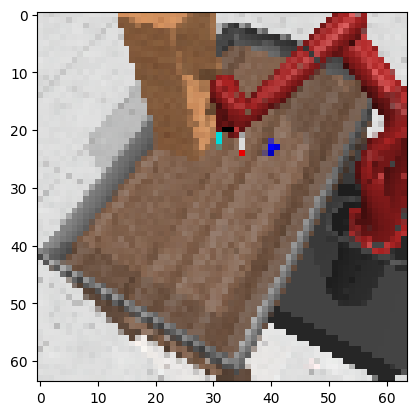

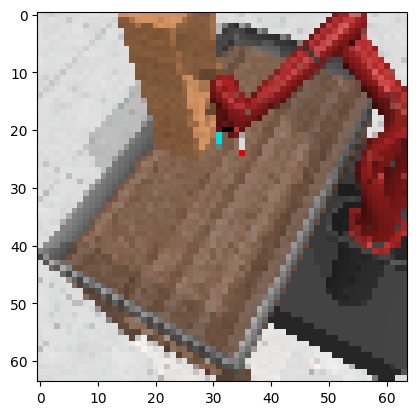

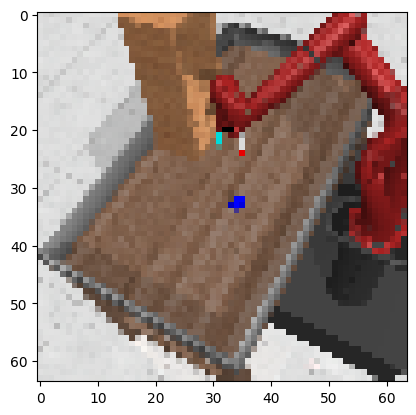

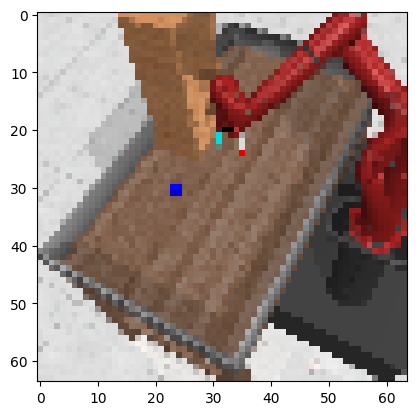

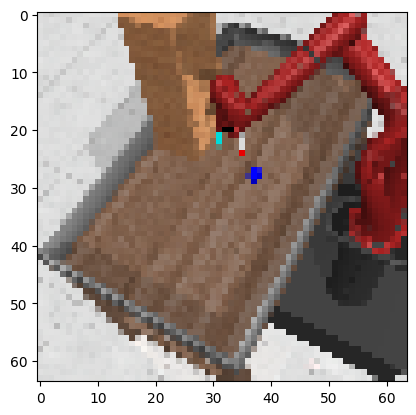

1it [00:25, 25.63s/it]

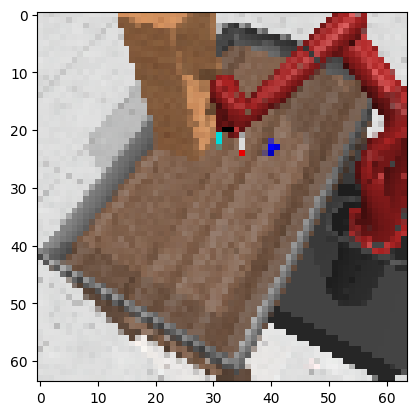

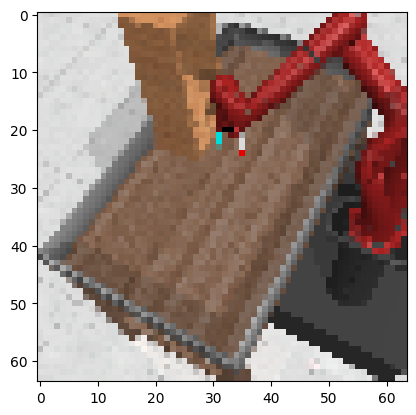

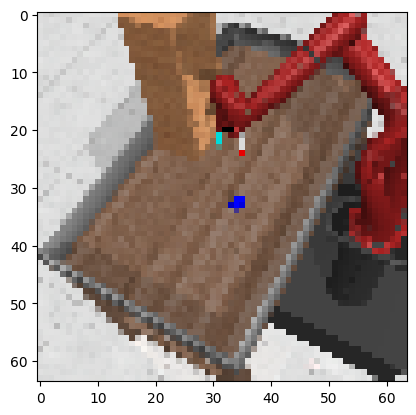

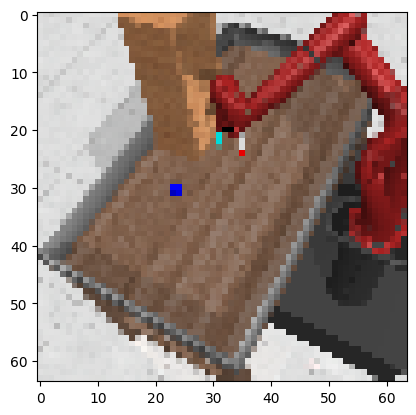

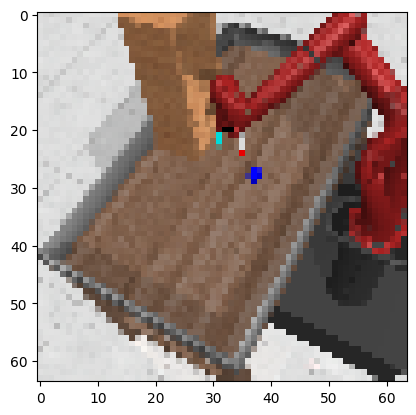

2it [00:51, 25.85s/it]

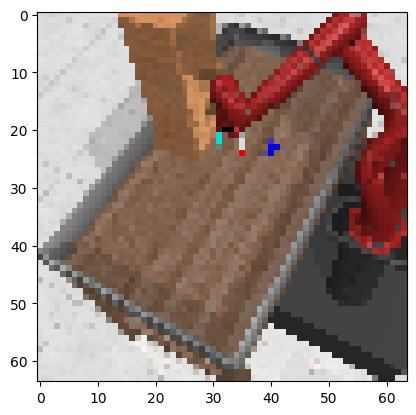

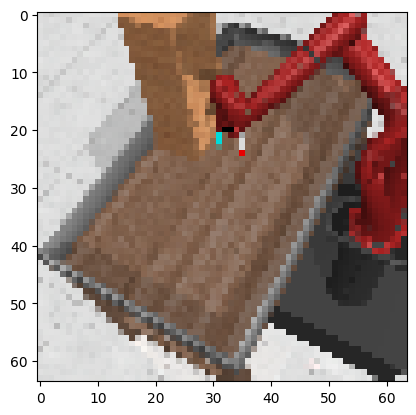

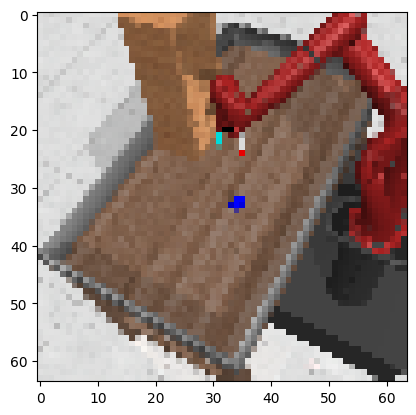

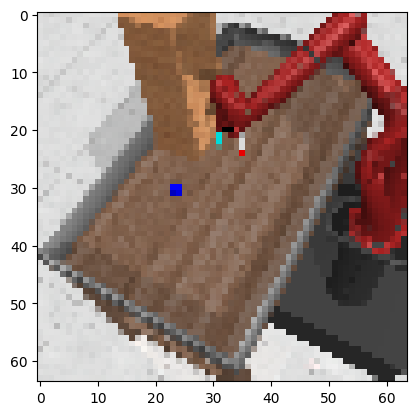

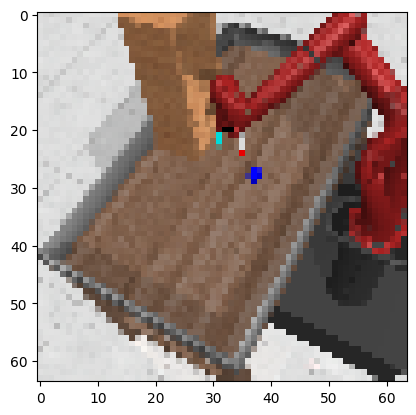

3it [01:17, 25.82s/it]
0it [00:00, ?it/s]

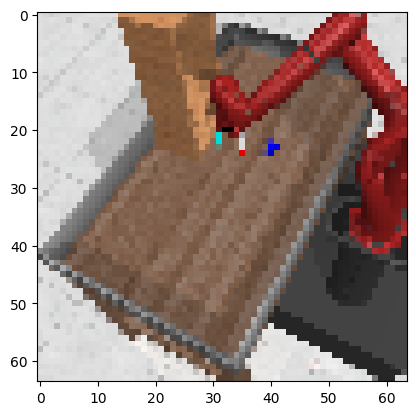

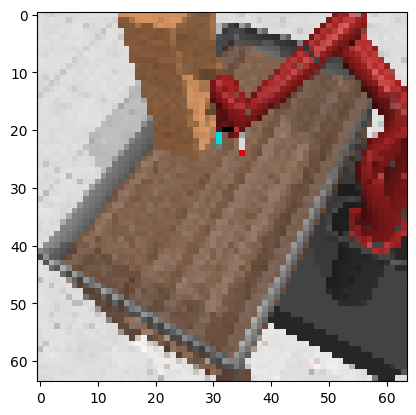

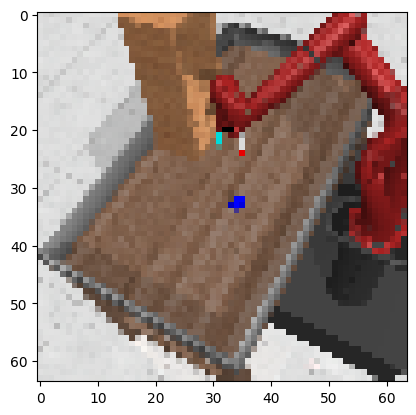

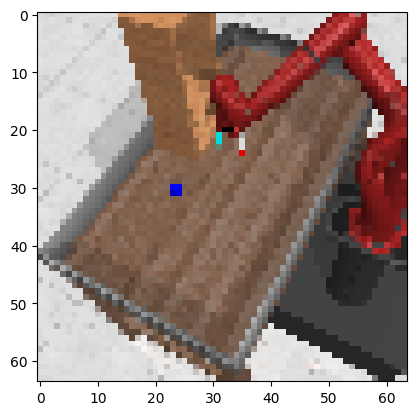

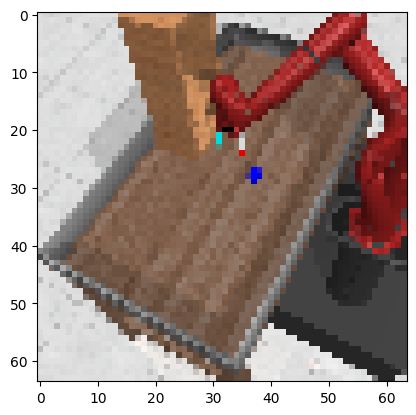

1it [00:26, 26.53s/it]

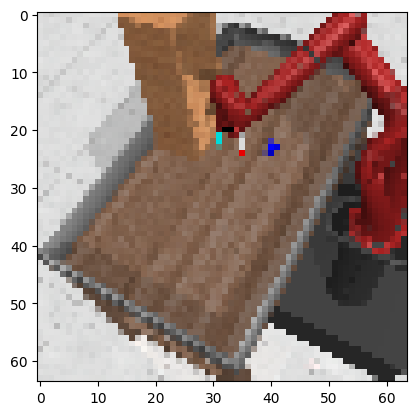

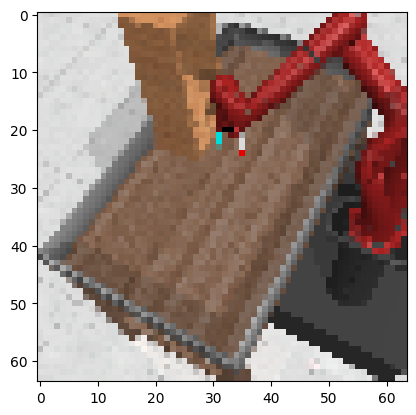

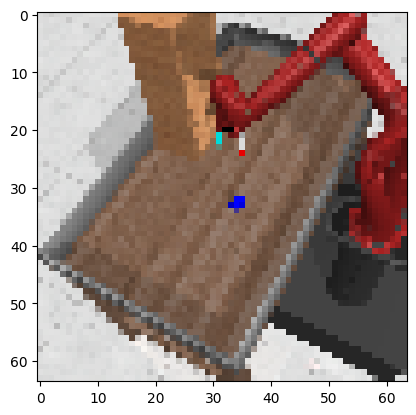

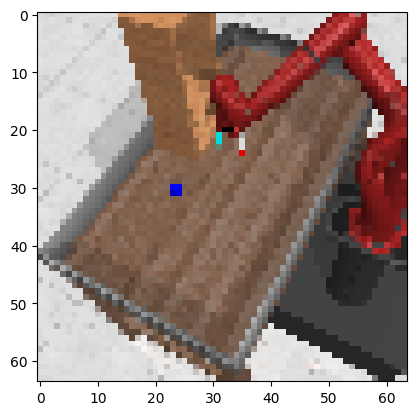

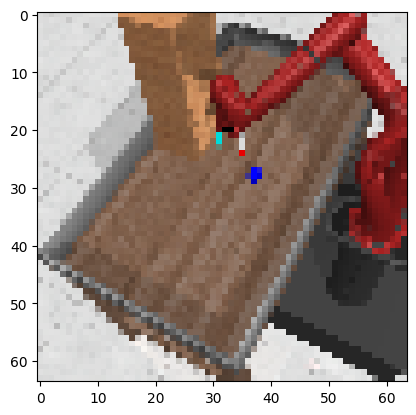

2it [00:55, 27.83s/it]

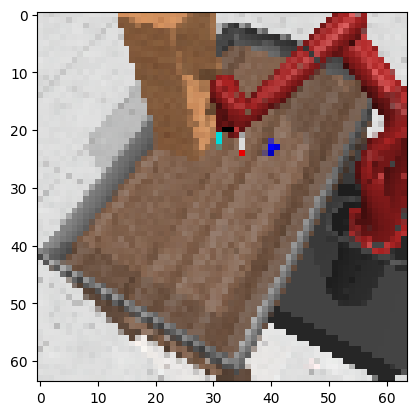

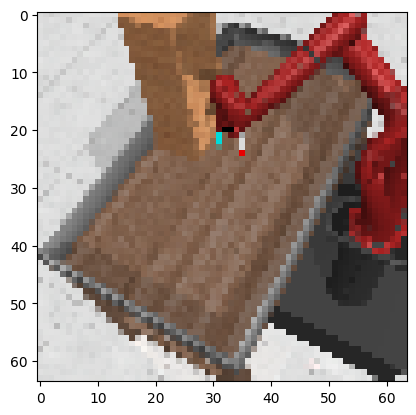

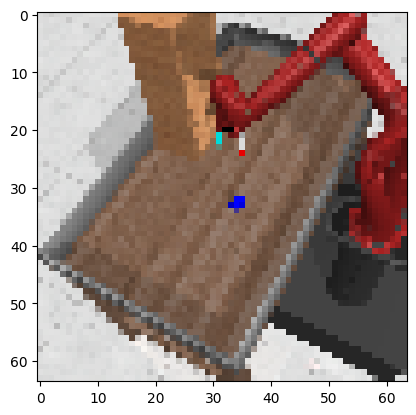

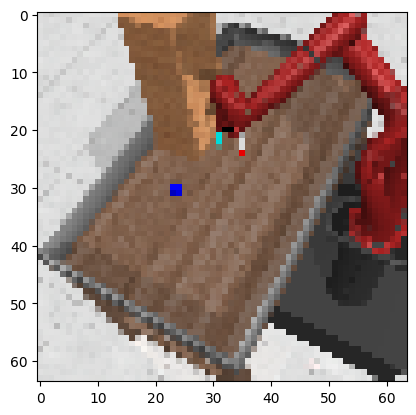

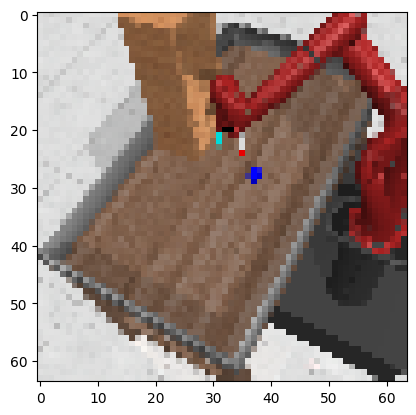

3it [01:23, 27.86s/it]


In [70]:
import imageio

save_files = True 
eval_benchmark = "offline_mw_benchmark_5"
eval_env.visualize_target = vis_target
cfg = models[eval_benchmark][0].cfg

horizon = eval_env.horizon
episodes = 5
eval_until_episode = utils.Until(episodes)
target_skill_inputs = ["pos", "obs"]
seeds = len(models[eval_benchmark])

move_to_target_metrics = {}
for target_skill_input in target_skill_inputs:
    move_to_target_metrics[target_skill_input] = [0] * seeds

vis_target_dir = lambda s: "vis_target_" if s else ""
save_dir = Path(f"notebooks/focus++ evaluations/multimodal_evals/{task2domain[task]}/{task}/{vis_target_dir(vis_target)}")

if not os.path.exists(save_dir):
    os.makedirs(save_dir)

for target_skill_input in target_skill_inputs:
    for s, agent in tqdm(enumerate(models[eval_benchmark])):
        obj_pos = np.zeros_like([cfg.env.object_start_pos]).astype(float) 
        video = np.empty([1, int(horizon/2) + 1 , 3, *cfg.env.renderer.size])
        episode = 0
        meta = agent.init_meta
        
        while eval_until_episode(episode):
            episode_data = []
            
            eval_env.reset()
            # pick random goal for evaluation
            target = eval_env.get_goal(episode)
            
            # set target before reset of env
            eval_env.set_target(target[1])                    
            agent.set_target(target[1]) 
            target_obs = get_target_observation(target[0])  
            
            plt.imshow(target_obs["rgb"].transpose(1,2,0))
            plt.show()
            
            tensor_target_obs = {
                k: torch.as_tensor(np.copy(v), device=agent.device).unsqueeze(0)
                for k, v in target_obs.items()
            }
            embed = agent.wm.encoder(agent.wm.preprocess(tensor_target_obs))
            
            warmup_cycles = 1
            latent = agent.wm.rssm.initial(len([target_obs["reward"]]))
            
            for i in range(warmup_cycles):
                latent, _ = agent.wm.rssm.obs_step(
                    latent,
                    tensor_target_obs["action"],
                    embed,
                    tensor_target_obs["is_first"],
                    should_sample=True
                    )
                
            f_i = agent.wm.rssm.get_feat(latent).unsqueeze(0)
            if target_skill_input == "obs":
                if agent.name == "skill_focus":
                    target_skill = agent.wm.heads["object_decoder"].object_latent_extractor(f_i.detach())["post"]["mean"][0,0,0,:].unsqueeze(0)
                elif agent.name == "lexa":
                    target_skill = f_i[0]
                    
            elif target_skill_input == "pos":
                target_skill = agent.wm.object_encoder(torch.tensor([[[target[1]]]], device="cuda", dtype=torch.float))["prior"]["mean"][0][0]
            
            obs = eval_env.reset()
            eval_env.set_target(target[1])                    

            # double for visualization purposes
            obs["eval_rgb"] = obs["rgb"]
            
            episode_data.append(obs)
            agent_state = None
            
            while not bool(obs["is_last"]):
                with torch.no_grad(), utils.eval_mode(agent):
                    action, agent_state = agent.act(
                        obs,
                        meta,
                        global_step,
                        eval_mode=True,
                        state=agent_state,
                        target_skill=target_skill
                    )
                obs = eval_env.step(action)
                
                # in case of dmc manipulator environment, the target position needs to update at every step, given the internal machanics
                if cfg.agent.train_target_reach:
                    obs["eval_rgb"] = eval_env.get_rgb_with_target()
                else:
                    obs["eval_rgb"] = obs["rgb"]

                episode_data.append(obs)
                total_reward += obs["reward"]
                step += 1
                obj_pos = np.concatenate((obj_pos, [obs["objects_pos"][0]]))

            # log moving average, move to target metrics
            if cfg.agent.train_target_reach:
                target_pos = agent._target_pos.cpu().numpy()
                if episode == 0:
                    episode_metrics = utils.move_to_target_metrics(obj_pos, target_pos)
                    move_to_target_metrics[target_skill_input][s] = {k: v / episodes for k, v in episode_metrics.items()}
                else:
                    episode_metrics = utils.move_to_target_metrics(obj_pos, target_pos)
                    move_to_target_metrics[target_skill_input][s] = {k: v / episodes + move_to_target_metrics[target_skill_input][s][k] for k, v in episode_metrics.items()}

            # video output for visualization                 
            if save_files:
                if episode==0:
                    video = np.expand_dims(np.stack([obs['eval_rgb'] for obs in episode_data], axis=0), axis=0)    
                else:
                    video = np.concatenate([video, np.expand_dims(np.stack([obs['eval_rgb'] for obs in episode_data], axis=0), axis=0)], axis=-1)    
                
            episode += 1
            total_success += obs["success"]
            obj_pos = np.zeros_like([cfg.env.object_start_pos]).astype(float) 
        
        if save_files:
            imageio.mimwrite(save_dir / f'{task}_{vis_target_dir(vis_target)}eval_{s}_{target_skill_input}.mp4', video[0].transpose(0,2,3,1), fps=15) 

Modality pos move_to_target_final: 0.6494628459245391 ± 0.06915977471191642
Modality obs move_to_target_final: 0.5581286333153512 ± 0.07748374995034313
Modality pos move_to_target_min: 0.7639131053246926 ± 0.06635786403209341
Modality obs move_to_target_min: 0.7037055492633418 ± 0.08238317842772727
Modality pos move_to_target_max: 0.2729999109067501 ± 0.009601673458722579
Modality obs move_to_target_max: 0.2816579462123963 ± 0.007989311480091412
Modality pos move_to_target_mean: 0.6434377764246125 ± 0.06533925878415814
Modality obs move_to_target_mean: 0.5476423804192878 ± 0.0676369830485527


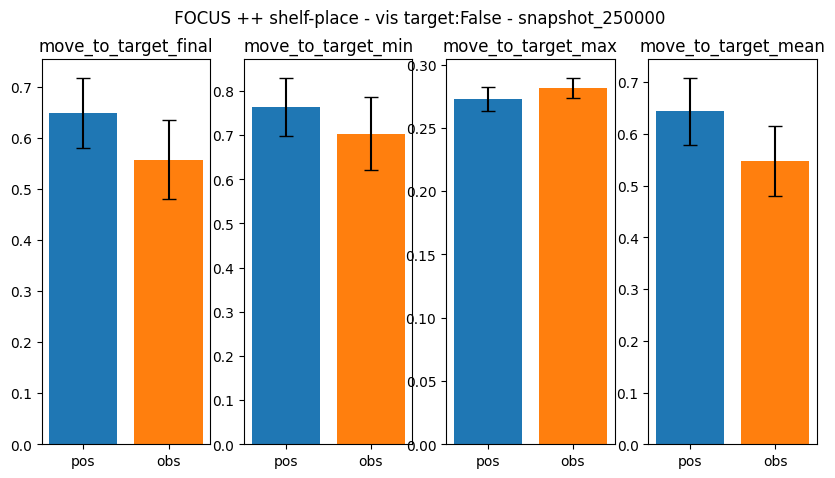

In [71]:
save_files = True

n_metrics = len(move_to_target_metrics["obs"][0].keys())
fig, axs = plt.subplots(1, n_metrics, figsize=(10, 5))
for i, metric in enumerate(move_to_target_metrics["obs"][0].keys()):
    for mod in move_to_target_metrics.keys():
        mean = np.mean([move_to_target_metrics[mod][s][metric] for s in range(seeds)])
        std = np.std([move_to_target_metrics[mod][s][metric] for s in range(seeds)])
        print(f"Modality {mod} {metric}: {mean} ± {std}")

        axs[i].bar(mod, mean, yerr=std, capsize=5, label=metric)
        axs[i].set_title(metric)
        
fig.suptitle(f" FOCUS ++ {task} - vis target:{vis_target} - {snapshot}")
vis_target_dir = lambda s: "vis_target_" if s else ""

if save_files:
    plt.savefig(save_dir / f'{task}_{vis_target_dir(vis_target)}.png')


In [14]:
len(models[eval_benchmark])

3

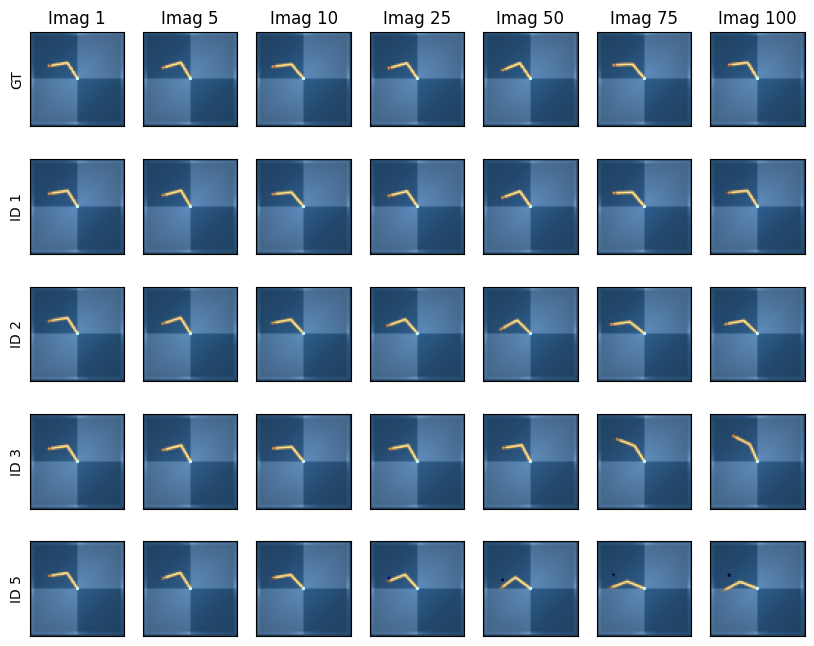

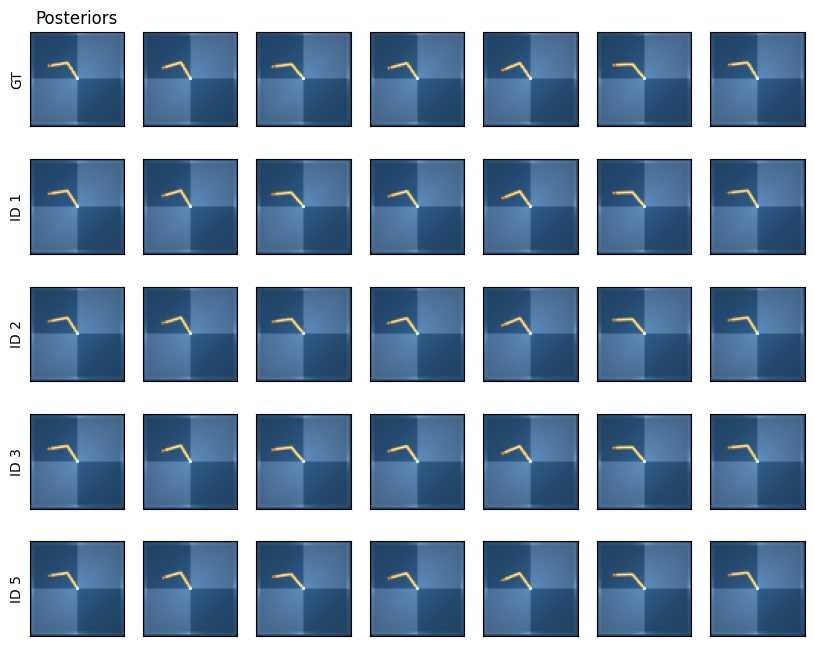

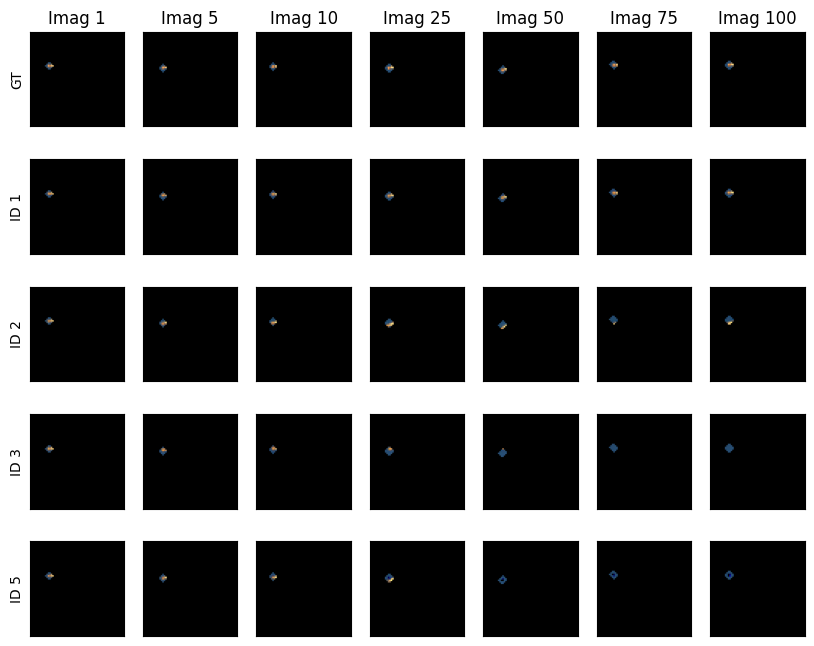

In [55]:
fig1, axs1 = plt.subplots(5, len(error_steps), figsize=(10, 8))
fig2, axs2 = plt.subplots(5, len(error_steps), figsize=(10, 8))
fig3, axs3 = plt.subplots(5, len(error_steps), figsize=(10, 8))


axs1[0, 0].set_ylabel(f"GT")
axs2[0, 0].set_ylabel(f"GT")
axs3[0, 0].set_ylabel(f"GT")


for i, id in enumerate(runs[task].keys()):
    axs1[i+1, 0].set_ylabel(f"ID {id}")
    axs2[i+1, 0].set_ylabel(f"ID {id}")
    axs3[i+1, 0].set_ylabel(f"ID {id}")
    

for i, s in enumerate(error_steps):
    axs1[0, i].imshow(det(truth[0, imag_start_step + s].permute(1,2,0)))
    axs1[0, i].set_title(f"Imag {s}")
    axs1[0, i].set_xticks([])
    axs1[0, i].set_yticks([])
    
    for y, id in enumerate(runs[task].keys()):
        axs1[y+1, i].imshow(det(prior_recons[task][id][0, s-1].permute(1,2,0)))
        axs1[y+1, i].set_xticks([])
        axs1[y+1, i].set_yticks([])

        
    axs2[0, i].imshow(det(truth[0, imag_start_step + s].permute(1,2,0)))
    axs2[0, 0].set_title(f"Posteriors")
    axs2[0, i].set_xticks([])
    axs2[0, i].set_yticks([])
    
    for y, id in enumerate(runs[task].keys()):
        axs2[y+1, i].imshow(det(post_recons[task][id][0, imag_start_step + s].permute(1,2,0)))
        axs2[y+1, i].set_xticks([])
        axs2[y+1, i].set_yticks([])

    axs3[0, i].imshow((truth_masked[0, imag_start_step + s].transpose(1,2,0)))
    axs3[0, i].set_xticks([])
    axs3[0, i].set_yticks([])
    
    for y, id in enumerate(runs[task].keys()):
        axs3[y+1, i].imshow(prior_recons_masked[task][id][0, s-1].transpose(1,2,0))
        axs3[0, i].set_title(f"Imag {s}")
        axs3[y+1, i].set_xticks([])
        axs3[y+1, i].set_yticks([])


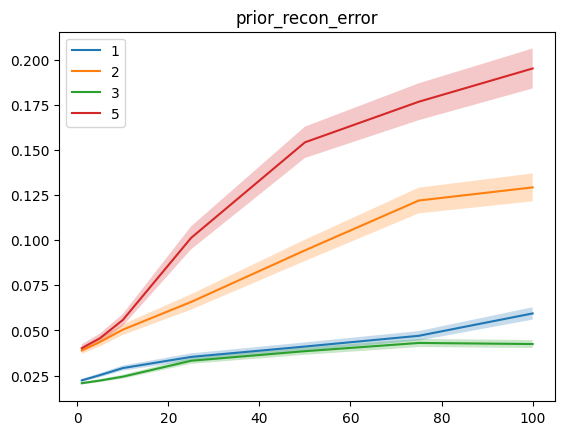

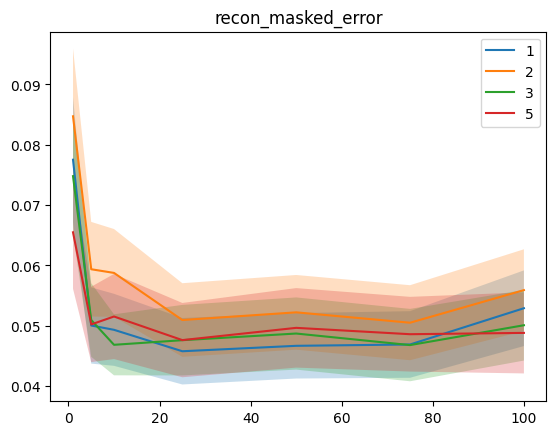

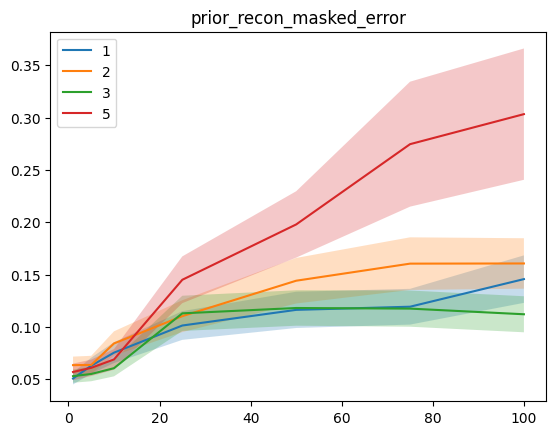

In [56]:
# for each img steps get a single mean value (with all the episodes)

# means = {}
# stds = {}

# for k, v in metrics.items():
#     means[k] = []
#     stds[k] = []
#     for i in range(len(v)):
#         means[k].append(np.array([x["mean"] for x in v[i]]).mean())
#         stds[k].append(np.array([x["std"] for x in v[i]]).mean())
        
plt.figure()
for id in runs[task].keys():
    
    means = [x[id][0]["mean"] for x in metrics["prior_recon_error"]]
    stds = [x[id][0]["std"] for x in metrics["prior_recon_error"]]    

    plt.plot(error_steps, means, label=id)
    plt.fill_between(error_steps, np.subtract(means, stds), np.add(means, stds), alpha=0.25)
    plt.legend()
    plt.title("prior_recon_error")
    
# plt.plot(error_steps, means["prior_recon_error"])
# plt.fill_between(error_steps, np.subtract(means["prior_recon_error"], stds["prior_recon_error"]), np.add(means["prior_recon_error"], stds["prior_recon_error"]), alpha=0.8)

plt.figure()
for id in runs[task].keys():
    
    means = [x[id][0]["mean"] for x in metrics["recon_masked_error"]]
    stds = [x[id][0]["std"] for x in metrics["recon_masked_error"]]
    # print(means)
    # print(stds)
    
    plt.plot(error_steps, means, label=id)
    plt.fill_between(error_steps, np.subtract(means, stds), np.add(means, stds), alpha=0.25)
    plt.legend()
    plt.title("recon_masked_error")
    
# plt.figure()
# plt.plot(error_steps, means["recon_masked_error"])
# plt.fill_between(error_steps, np.subtract(means["recon_masked_error"], stds["recon_masked_error"]), np.add(means["recon_masked_error"], stds["recon_masked_error"]), alpha=0.8)

plt.figure()
for id in runs[task].keys():
    
    means = [x[id][0]["mean"] for x in metrics["prior_recon_masked_error"]]
    stds = [x[id][0]["std"] for x in metrics["prior_recon_masked_error"]]
    # print(means)
    # print(stds)
    
    plt.plot(error_steps, means, label=id)
    plt.fill_between(error_steps, np.subtract(means, stds), np.add(means, stds), alpha=0.25)
    plt.legend()
    plt.title("prior_recon_masked_error")
    
# plt.figure()
# plt.plot(error_steps, means["prior_recon_masked_error"])
# plt.fill_between(error_steps, np.subtract(means["prior_recon_masked_error"], stds["prior_recon_masked_error"]), np.add(means["prior_recon_masked_error"], stds["prior_recon_masked_error"]), alpha=0.8)
        